# Lung Data (He et al., 2022)

He, S. et al. High-plex imaging of RNA and proteins at subcellular resolution in fixed tissue by spatial molecular imaging. Nat Biotechnol 40, 1794–1806 (2022).

In [1]:
import scanpy as sc
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt

## Help functions

In [2]:
def nr_connected_nodes(adj_matrix):
    # Check which nodes are connected (rows with at least one non-zero element)
    connected_nodes = np.array((adj_matrix != 0).sum(axis=1)).flatten() > 0

    # Count the number of connected nodes
    num_connected_nodes = np.sum(connected_nodes)

    # Total number of nodes (same as the number of rows or columns in the adjacency matrix)
    total_nodes = adj_matrix.shape[0]

    # Calculate the percentage of connected nodes
    percentage_connected_nodes = (num_connected_nodes / total_nodes) * 100
    
    return percentage_connected_nodes

## Load data

In [3]:
nicheformer_database = '/lustre/groups/ml01/projects/2023_nicheformer_data_anna.schaar/spatial/preprocessed/human/nanostring_lung_annotated.h5ad'
HE22_HUMAN_LUNG_DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad'

In [4]:
adata = sc.read_h5ad(HE22_HUMAN_LUNG_DATA_PATH)
adata

AnnData object with n_obs × n_vars = 771203 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'spatial'
    layers: 'log1p', 'raw'
    obsp: 'adj_matrix_connectivities', 'adj_matrix_distances', 'c

#### Obs variables:

- **author_cell_type** [18]: 'B-cell', 'NK', 'T CD4 memory', 'T CD4 naive', 'T CD8 memory', 'T CD8 naive', 'Treg', 'endothelial', 'epithelial', 'fibroblast', 'mDC', 'macrophage', 'mast', 'monocyte', 'neutrophil', 'pDC', 'plasmablast', 'tumor'
- **library_key** [8]: [0, 1, 2, 3, 4, 5, 6, 7]
    - indicating the FOV
- **donor_id** [5]: 'Lung12', 'Lung13', 'Lung5', 'Lung6', 'Lung9'


# Preprocessing

In [7]:
tumor_cell_ctypes = ['tumor 12', 'tumor 13', 'tumor 5', 'tumor 6', 'tumor 9']
for tumor in tumor_cell_ctypes:
    adata.obs['author_cell_type'] = adata.obs['author_cell_type'].replace(tumor, 'tumor')
np.unique(adata.obs['author_cell_type'])

array(['B-cell', 'NK', 'T CD4 memory', 'T CD4 naive', 'T CD8 memory',
       'T CD8 naive', 'Treg', 'endothelial', 'epithelial', 'fibroblast',
       'mDC', 'macrophage', 'mast', 'monocyte', 'neutrophil', 'pDC',
       'plasmablast', 'tumor'], dtype=object)

In [10]:
# need to convert from string to 
# import pandas as pd
# adata = adata[~pd.isnull(adata.obs['window'])]
# adata

In [47]:
donor_id_str = adata.obs['donor_id'].astype(str)
library_key_str = adata.obs['library_key'].astype(str)
adata.obs['sample_id'] = donor_id_str + '_' + library_key_str
print(np.unique(adata.obs['sample_id']))

['Lung12_6' 'Lung13_7' 'Lung5_0' 'Lung5_1' 'Lung5_2' 'Lung6_3' 'Lung9_4'
 'Lung9_5']


In [81]:
print(len(np.unique(adata.obs['window'])))
print(len(np.unique(adata.obs['cell_ID'])))

375
5508


In [6]:
niche_array = np.unique(adata.obs['niche'])
print(f'Number of niches: ', len(niche_array))
print(niche_array)

Number of niches:  9
['immune' 'lymphoid structure' 'macrophages' 'myeloid-enriched stroma'
 'neutrophils' 'plasmablast-enriched stroma' 'stroma' 'tumor interior'
 'tumor-stroma boundary']


In [15]:
cell_type_array = np.unique(adata.obs['author_cell_type'])
print(f'Number of cell types: ', len(cell_type_array))
print(cell_type_array)

Number of cell types:  18
['B-cell' 'NK' 'T CD4 memory' 'T CD4 naive' 'T CD8 memory' 'T CD8 naive'
 'Treg' 'endothelial' 'epithelial' 'fibroblast' 'mDC' 'macrophage' 'mast'
 'monocyte' 'neutrophil' 'pDC' 'plasmablast' 'tumor']


# Visualization

In [10]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


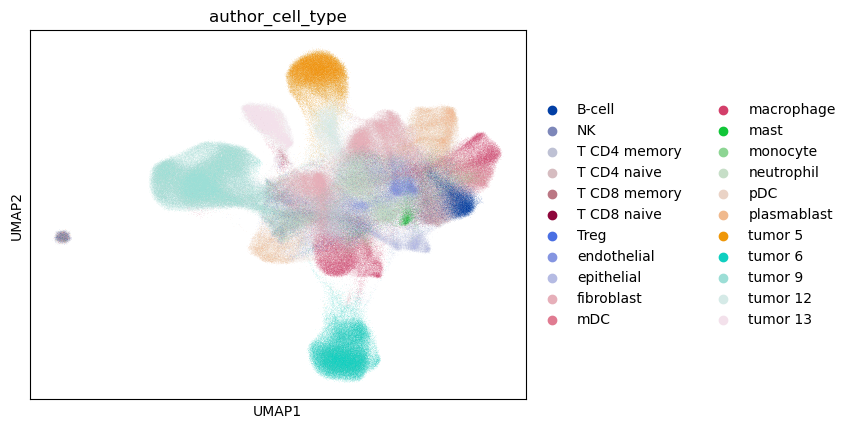

In [ ]:
sc.pl.umap(adata, color = ["author_cell_type"])

## Spatial Graph: Neighbors 

In [14]:
LIBRARY_KEY = "library_key"

In [6]:
adata.obs[LIBRARY_KEY] = adata.obs[LIBRARY_KEY].astype("category")

In [15]:
sq.gr.spatial_neighbors(adata, key_added = 'adj_matrix', spatial_key = 'spatial', library_key = LIBRARY_KEY, radius = 30, coord_type= 'generic')

In [9]:
percentage_connected_nodes = []
#for lib_key, sample_id in zip(np.unique(adata.obs[LIBRARY_KEY]), np.unique(adata.obs['sample_id'])):
for lib_key in np.unique(adata.obs[LIBRARY_KEY]):
    adj_matrix = adata.obsp['adj_matrix_connectivities'][adata.obs[LIBRARY_KEY]==lib_key]
    total_values = adj_matrix.shape[0]
    non_zero_elements = adj_matrix.nnz

    percentage_connected_nodes.append(nr_connected_nodes(adj_matrix))

    #Print the results
    #print(f"Patient {sample_id}")
    print(f"Total number of values (cells) in the matrix: {total_values}")
    print(f"Number of non-zero elements (edges) in the matrix: {non_zero_elements}")
    print(f"Percentage of connected nodes: {percentage_connected_nodes[-1]:.2f}%")

print(f'Min: {min(percentage_connected_nodes)}, Max: {max(percentage_connected_nodes)}, Avg: {sum(percentage_connected_nodes) / len(percentage_connected_nodes)}')

Total number of values (cells) in the matrix: 1169
Number of non-zero elements (edges) in the matrix: 42
Percentage of connected nodes: 3.59%
Total number of values (cells) in the matrix: 2573
Number of non-zero elements (edges) in the matrix: 244
Percentage of connected nodes: 9.06%
Total number of values (cells) in the matrix: 2527
Number of non-zero elements (edges) in the matrix: 206
Percentage of connected nodes: 7.95%
Total number of values (cells) in the matrix: 2304
Number of non-zero elements (edges) in the matrix: 114
Percentage of connected nodes: 4.86%
Total number of values (cells) in the matrix: 1714
Number of non-zero elements (edges) in the matrix: 46
Percentage of connected nodes: 2.68%
Total number of values (cells) in the matrix: 1524
Number of non-zero elements (edges) in the matrix: 68
Percentage of connected nodes: 4.40%
Total number of values (cells) in the matrix: 1816
Number of non-zero elements (edges) in the matrix: 102
Percentage of connected nodes: 5.29%
To

In [ ]:
for lib_key in ['library_key', 'window']:
    sq.gr.spatial_neighbors(adata, key_added = 'adj_matrix', spatial_key = 'spatial', library_key = lib_key, radius = 50, coord_type= 'generic')
    # number of neighbors
    
    

## Split in windows

How  many k-hops for 2k-3k big graphs?

Inspired by Kusami function
- how to get size? 
- what is size varies per FOV? 

In [168]:
subadata = adata[adata.obs['library_key'] == 0]
subadata

View of AnnData object with n_obs × n_vars = 98000 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'spatial'
    layers: 'log1p', 'raw'
    obsp: 'adj_matrix_connectivities', 'adj_matrix_distanc

In [171]:
def sliding_windows(adata, window_size, overlap: int = 0):
    """
        Input:
            - nr_windows: number of windows 
            - overlap: 
    """
    adata.obs['sliding_window'] = 'NaN'
    width = adata.obs['x'].max() - adata.obs['x'].min()
    length = adata.obs['y'].max() - adata.obs['y'].min()
    
    nr_windows_per_row = np.ceil(np.divide(width, window_size))
    nr_windows_per_col = np.ceil(np.divide(length, window_size))
    print(nr_windows_per_row, nr_windows_per_col)

    for row in range(1, int(nr_windows_per_row)+1):
        x_min = adata.obs['x'].min() + (row-1)*window_size 
        x_max = adata.obs['x'].min() + row*window_size
        for col in range(1, int(nr_windows_per_col)+1):
            y_min = adata.obs['y'].min() + (col-1)*window_size
            y_max = adata.obs['y'].min() + col*window_size
            mask = (adata.obs['x'] >= x_min) & (adata.obs['x'] < x_max) & (adata.obs['y'] >= y_min) & (adata.obs['y'] < y_max)
            adata.obs.loc[mask, 'sliding_window'] = f'{row}_{col}'

    return subadata

In [170]:
subadata = sliding_windows(subadata, 7000, overlap=0)
subadata

/tmp/ipykernel_1033572/1402928805.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sliding_window'] = 'NaN'


4.0 4.0


AnnData object with n_obs × n_vars = 98000 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'donor_id', 'author_cell_type', 'library_key', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', '_scvi_batch', '_scvi_labels', 'window', 'sliding_window'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'adj_matrix_neighbors', 'log1p', 'neighbors', 'niche', 'niche_colors', 'schema_version', 'title', 'umap'
    obsm: 'X_pca', 'X_scvi', 'spatial'
    layers: 'log1p', 'raw'
    obsp: 'adj_matrix_connectivities', 'adj_matr

In [167]:
cells_per_window = subadata.obs.groupby('sliding_window').size()
print(f'Cells per window stats: Max: {cells_per_window.max()}, MIN: {cells_per_window.min()}, mean: {cells_per_window.mean()}, nr. of windows: {len(cells_per_window)}')

Cells per window stats: Max: 9635, MIN: 980, mean: 6125.0, nr. of windows: 16


In [146]:
subadata.obs['sliding_window']

1_1        1_1
2_1        1_1
3_1        1_1
4_1        1_1
5_1        1_1
          ... 
4750_30    4_3
4751_30    4_3
4752_30    4_3
4753_30    4_3
4755_30    4_3
Name: sliding_window, Length: 98000, dtype: category
Categories (16, object): ['1_1', '1_2', '1_3', '1_4', ..., '4_1', '4_2', '4_3', '4_4']

In [173]:
subadata.obs['sliding_window'] = subadata.obs['sliding_window'].astype("category")

In [156]:
sq.gr.spatial_neighbors(subadata, key_added = 'adj_matrix', spatial_key = 'spatial', library_key = 'library_key', radius = 30, coord_type= 'generic')

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


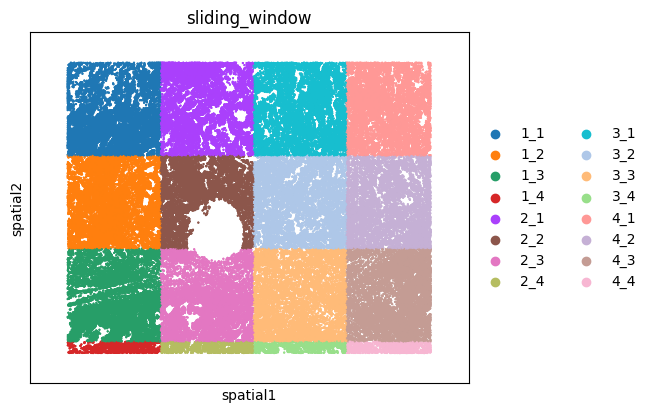

In [164]:
sq.pl.spatial_scatter(
    subadata,
    spatial_key = 'spatial',
    shape=None,
    #library_key='library_key', 
    library_id = [0], #['0_0_0', '0_0_1'],
    color="sliding_window",
    #groups=['immune', 'stroma'],
    connectivity_key="adj_matrix_connectivities",
    #size = 2,
    #edges_width=10.0, edges_color='red'
)

In [179]:
sq.gr.spatial_neighbors(subadata, key_added = 'adj_matrix', spatial_key = 'spatial', library_key = 'sliding_window', radius = 50, coord_type= 'generic')

In [180]:
percentage_connected_nodes = []
#for lib_key, sample_id in zip(np.unique(adata.obs[LIBRARY_KEY]), np.unique(adata.obs['sample_id'])):
for lib_key in np.unique(subadata.obs['sliding_window']):
    adj_matrix = subadata.obsp['adj_matrix_connectivities'][subadata.obs['sliding_window']==lib_key]
    total_values = adj_matrix.shape[0]
    non_zero_elements = adj_matrix.nnz

    percentage_connected_nodes.append(nr_connected_nodes(adj_matrix))

    #Print the results
    #print(f"Patient {sample_id}")
    print(f"Total number of values (cells) in the matrix: {total_values}")
    print(f"Number of non-zero elements (edges) in the matrix: {non_zero_elements}")
    print(f"Percentage of connected nodes: {percentage_connected_nodes[-1]:.2f}%")

print(f'Min: {min(percentage_connected_nodes)}, Max: {max(percentage_connected_nodes)}, Avg: {sum(percentage_connected_nodes) / len(percentage_connected_nodes)}')

Total number of values (cells) in the matrix: 9337
Number of non-zero elements (edges) in the matrix: 11790
Percentage of connected nodes: 69.19%
Total number of values (cells) in the matrix: 9635
Number of non-zero elements (edges) in the matrix: 10882
Percentage of connected nodes: 67.41%
Total number of values (cells) in the matrix: 7861
Number of non-zero elements (edges) in the matrix: 6932
Percentage of connected nodes: 59.15%
Total number of values (cells) in the matrix: 980
Number of non-zero elements (edges) in the matrix: 736
Percentage of connected nodes: 56.33%
Total number of values (cells) in the matrix: 8201
Number of non-zero elements (edges) in the matrix: 8978
Percentage of connected nodes: 65.43%
Total number of values (cells) in the matrix: 6371
Number of non-zero elements (edges) in the matrix: 6044
Percentage of connected nodes: 58.84%
Total number of values (cells) in the matrix: 7465
Number of non-zero elements (edges) in the matrix: 7078
Percentage of connected